# Sentiment Analysis of Tweets on Tech Products

# Chapter 1: Business Understanding

## 1.1 Background Information

In today’s digital age, consumers constantly share their opinions online about various topics an products through reviews, tweets, and forums. These opinions hold valuable insights for technology companies that rely heavily on user experience and brand perception. Understanding public sentiment helps firms make data-driven product, marketing, and customer experience decisions.

This project is undertaken by Lingua Franca Data Elites, a data-driven consulting firm specializing in artificial intelligence solutions for business intelligence and brand analytics. Lingua Franca has been contracted to conduct a sentiment analysis on customer reviews and discussions surrounding Google and Apple products. With both brands dominating the global tech landscape, analyzing how customers perceive their products across online platforms can reveal comparative advantages, recurring complaints, and evolving brand loyalty trends.

The motivation for this analysis arises from the increasing competition in the consumer technology market. Both Google and Apple continuously release innovative hardware and software products, yet their customer satisfaction levels and public sentiment fluctuate based on product performance, pricing, design, and ecosystem integration. Understanding these sentiments provides an opportunity for firms and investors to forecast brand performance, guide marketing strategies, and identify product improvement areas.

--- 


## 1.2 Problem Statement

Despite the abundance of online reviews and discussions, companies often struggle to systematically analyze this data to extract actionable insights. Manual review analysis is time-consuming, subjective, and impractical given the volume of data generated daily.

This project aims to develop a Natural Language Processing (NLP) model that automatically classifies and interprets user sentiment (positive, negative, or neutral) toward Google and Apple products. By analyzing patterns and themes within the text data, the project seeks to answer key business questions such as:

* How do users perceive Google versus Apple products in terms of satisfaction and quality?
* What product features drive the strongest positive or negative emotions?
* How has sentiment evolved over time for each brand?
* Are there recurring issues or praise patterns that can inform future product development and customer engagement?

---

## 1.3 Project Objectives

### General Objective:

To build and evaluate an NLP model capable of accurately predicting and interpreting customer sentiment regarding Google and Apple products, providing actionable insights for strategic decision-making.

### Specific Objectives:

1. To perform data cleaning and exploratory data analysis to understand trends and key topics in user reviews.
2. To develop a baseline machine learning model (TF-IDF + Logistic Regression) for sentiment classification.
3. To fine-tune a transformer-based NLP model (e.g., BERT or DistilBERT) for improved sentiment prediction accuracy.
4. To conduct error and interpretability analysis to understand which words or phrases drive sentiment outcomes.
5. To compare sentiment distributions between Google and Apple products and highlight areas of strength or improvement for each brand.
6. To visualize sentiment trends and generate a dashboard/report for business stakeholders.

---

##  1.4 Metrics of Success

The success of this sentiment analysis project will be evaluated using both **quantitative model performance metrics** and **qualitative business outcomes**, each with clear numerical targets to guide model development and evaluation.

---

### a) Model Performance Metrics

| **Metric** | **Definition / Purpose** | **Baseline Target (TF-IDF + Logistic Regression)** | **Advanced Model Target (DistilBERT/BERT)** | **Business Interpretation** |
|-------------|---------------------------|----------------------------------------------------|---------------------------------------------|-----------------------------|
| **Accuracy** | Proportion of correctly classified reviews. | ≥ **75%** | ≥ **85–90%** | Reflects overall reliability in labeling sentiments correctly. |
| **Precision (Positive Class)** | Out of all predicted positive reviews, how many are actually positive. | ≥ **70%** | ≥ **85%** | High precision means fewer false positives — ideal for confident marketing insights. |
| **Recall (Negative Class)** | Out of all actual negative reviews, how many are detected by the model. | ≥ **70%** | ≥ **85%** | Ensures that major customer complaints are not missed. |
| **Macro F1-Score** *(Primary Metric)* | Harmonic mean of precision & recall across all classes. | ≥ **72%** | ≥ **87–90%** | Balanced measure ensuring fair performance across positive, neutral, and negative sentiments. |
| **Confusion Matrix** | Distribution of predictions per class. | Misclassification < **25%** overall | Misclassification < **10–15%** overall | Helps diagnose bias toward dominant sentiment classes. |
| **ROC-AUC (Binary View)** | Area under the ROC curve. | ≥ **0.80** | ≥ **0.92** | Measures the model’s ability to distinguish positive vs. negative classes. |

---

### b) Business-Level Success Indicators

| **Indicator** | **Target** | **Interpretation** |
|----------------|------------|--------------------|
| **Sentiment distribution clarity** | ≥ **70%** of reviews confidently classified (probability > 0.8) | Ensures reliable and actionable sentiment breakdowns. |
| **Insight generation** | Identify **top 5 drivers** of positive and negative sentiment. | Provides concrete recommendations for product and marketing teams. |
| **Visualization quality** | Dashboard with ≥ **3 key visual layers** (trend, brand comparison, key terms). | Demonstrates interpretability and usability of findings for business stakeholders. |

---

### c) Success Threshold Summary

- **Acceptable:** Macro F1 ≥ **0.72**, Accuracy ≥ **75%** (Baseline)  
- **Target:** Macro F1 ≥ **0.87**, Accuracy ≥ **85%** (DistilBERT)  
- **Excellent:** Macro F1 ≥ **0.90**, Accuracy ≥ **88–90%**, with actionable sentiment insights and clear interpretability visuals  

---

## 1.5 Expected Insights

By the end of this project, Lingua Franca Data Elites  expects to uncover meaningful insights that can influence both marketing and product strategies, including:

* Comparative sentiment analysis between Google and Apple, highlighting consumer preference patterns.

* Key drivers of satisfaction (e.g., design, usability, ecosystem) versus frustration (e.g., price, battery, compatibility).

* Temporal trends showing how major product launches or updates affect public opinion.

* Actionable recommendations for brand positioning and product improvement initiatives.


# Chapter 2: Data Understanding

This phase marks the beginning of the analytical process after defining the business objectives. Here, we seek to familiarize ourselves with the dataset, identify its structure, assess data quality, and determine its suitability for the modeling task.

For this project, we are working with the **“Brands and Product Emotions”** dataset obtained from **CrowdFlower (via [data.world](https://data.world/crowdflower/brands-and-product-emotions))**.  
This dataset contains tweets where users express emotions about different **brands and products** such as Apple, Google, Samsung, and others.  

Our goal is to focus on **tweets expressing emotions directed specifically at Apple and Google**, and use this text data to perform **sentiment analysis**.  
By analyzing these tweets, we aim to uncover patterns in how people feel about these two tech giants — identifying emotional tone, frequency of mentions, and differences in brand perception.

During this phase, we will:
- Examine the dataset’s overall structure and content.  
- Assess the completeness and cleanliness of the text data.  
- Understand the variables and their meanings.  

This understanding will form the foundation for subsequent stages.

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import warnings
warnings.filterwarnings('ignore')

# Importing sklearn libraries
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report,\
      precision_score, roc_curve, ConfusionMatrixDisplay 
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC,LinearSVC
from sklearn.naive_bayes import MultinomialNB



# Importing nltk 
import nltk
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
# Loading the dataset
df = pd.read_csv('judge-1377884607_tweet_product_company.csv', encoding = 'latin-1')

# Previewing the first five rows
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [3]:
# Previewing the last five rows
df.tail()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
9088,Ipad everywhere. #SXSW {link},iPad,Positive emotion
9089,"Wave, buzz... RT @mention We interrupt your re...",NaN,No emotion toward brand or product
9090,"Google's Zeiger, a physician never reported po...",NaN,No emotion toward brand or product
9091,Some Verizon iPhone customers complained their...,NaN,No emotion toward brand or product
9092,Ï¡Ïàü_ÊÎÒ£Áââ_£â_ÛâRT @...,NaN,No emotion toward brand or product


**Observation**: The dataset is uniform from top to bottom.

In [4]:
# Checking the shape
print(f" The dataset has {df.shape[0]} records and {df.shape[1]} features")

 The dataset has 9093 records and 3 features


In [5]:
# Checking the data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9092 non-null   object
 1   emotion_in_tweet_is_directed_at                     3291 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


**Observation**: 
1. All the columns in the dataset are categorical.
2. We note that there are some columns with missing values which will need to be handled.

In [6]:
# Checking statistical summary
df.describe().T

,count,unique,top,freq
tweet_text,9092,9065,RT @mention Marissa Mayer: Google Will Connect...,5
emotion_in_tweet_is_directed_at,3291,9,iPad,946
is_there_an_emotion_directed_at_a_brand_or_product,9093,4,No emotion toward brand or product,5389


**Observations**: 
* There are 9065 unique tweets. There may be need to check for duplicates.
* There are 9 unique products that the emotions are directed at. There may be need to feature engineer tojust have 2 categories either Apple or Google.
* There are 4 unique sentiments. However, they are meant to be 3 therefore there may be need to clean the column and standardize the text.
* The top emotion_in_tweet_is_directed_at iPad with 946 occurrences.
* The top emotion directed at a brand or product is no emotion toward brand or product with 5389 occurrences.

# Chapter 3: Data Preparation

Data Preparation converts the raw tweets into a clean, consistent, model-ready dataset. Guided by the schema below, this phase has two parts: **data cleaning** and **feature engineering**.

From the Data Understanding phase, we were able to gain the following information:

| Column name | Description | Notes on pre-processing |
|---|---|---|
| tweet_text | Raw tweet content authored by a user. | Clean minimal (URLs, @mentions, extra whitespace); keep casing for transformers; compute length stats (chars/tokens). |
| emotion_in_tweet_is_directed_at | The **brand/product** the emotion targets. | Impute missing from `tweet_text` with simple regex; then **map** to 3 buckets: **Apple Product / Google Product / Android Product**. |
| is_there_an_emotion_directed_at_a_brand_or_product | Whether the tweet expresses an emotion toward a brand/product. | Validate label consistency. |

In [7]:
# Creating a copy to retain the original dataset
data = df.copy(deep = True)

In [8]:
#checking the column names
data.columns

Index(['tweet_text', 'emotion_in_tweet_is_directed_at',
       'is_there_an_emotion_directed_at_a_brand_or_product'],
      dtype='object')

In [9]:
# Renaming the column names for ease of understanding
data.rename(columns = {'emotion_in_tweet_is_directed_at': 'product_name','is_there_an_emotion_directed_at_a_brand_or_product': 'emotion'}, inplace = True)

# checking if the column names have changed
data.columns

Index(['tweet_text', 'product_name', 'emotion'], dtype='object')

In [10]:
#Checking for duplicates
data.duplicated().sum()

np.int64(22)

**Observations**: There are 22 duplicated rows in the dataset.

In [11]:
# Dropping duplicates
data.drop_duplicates(inplace = True)

In [12]:
# Checking if the duplicates have been dropped
data.duplicated().sum()

np.int64(0)

In [13]:
# Checking for null values
data.isna().sum()

tweet_text         1
product_name    5789
emotion            0
dtype: int64

**Observations**: There is one null value in tweet_text and 5802 null values in emotion_in_tweet_is_directed_at columns.

In [14]:
# Dropping the rows with the missing value in tweet_text
data.dropna(subset = ['tweet_text'], inplace= True)

#checking if the row has been dropped
data.isna().sum()

tweet_text         0
product_name    5788
emotion            0
dtype: int64

In [15]:
# Checking for unique values in product_name
data['product_name'].unique()

array(['iPhone', 'iPad or iPhone App', 'iPad', 'Google', nan, 'Android',
       'Apple', 'Android App', 'Other Google product or service',
       'Other Apple product or service'], dtype=object)

In [16]:
def preprocess_text(text, remove_stopwords=True, lemmatize=True):
    """
    Comprehensive text preprocessing
    
    Steps:
    1. Convert to lowercase
    2. Remove URLs
    3. Remove mentions (@username)
    4. Remove hashtags
    5. Remove special characters
    6. Remove extra whitespace
    7. Tokenize
    8. Remove stopwords 
    9. Lemmatize
    """
    if pd.isna(text):
        return ""
    # Convert to lowercase
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove mentions
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtags (keep the word)
    text = re.sub(r'#', '', text)
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords
    if remove_stopwords:
        stop_words = set(stopwords.words('english'))
        # Keep some important words for sentiment
        keep_words = {'not', 'no', 'nor', 'neither', 'never', 'none'}
        stop_words = stop_words - keep_words
        tokens = [word for word in tokens if word not in stop_words]
    
    # Lemmatize
    if lemmatize:
        lemmatizer = WordNetLemmatizer()
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    # Join back into string
    text = ' '.join(tokens)
    
    return text

# Apply preprocessing
print("Preprocessing tweets...")
data['cleaned_tweet_text'] = df['tweet_text'].apply(lambda x: preprocess_text(x, remove_stopwords=True, lemmatize=True))
data['cleaned_tweet_text'].head()

Preprocessing tweets...


0    g iphone hr tweeting riseaustin dead need upgr...
1    know awesome ipadiphone app youll likely appre...
2                         not wait ipad also sale sxsw
3    hope year festival isnt crashy year iphone app...
4    great stuff fri sxsw marissa mayer google tim ...
Name: cleaned_tweet_text, dtype: object

In [17]:
# feature engineer name
def exact_name(text):
    match = re.search(r'\b(iphone|ipad|google| iphone app|android|apple|android app|ios|imac|mac|icloud|imessage|itunes|siri|gmail|chrome|\
                      assistant|pixel|nexus|play store|ipad2|ipads)\b', text)
    if match:
        return match.group(1)
    return np.nan

data["extracted_product"] = data["cleaned_tweet_text"].apply(exact_name)
data.head()

,tweet_text,product_name,emotion,cleaned_tweet_text,extracted_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion,g iphone hr tweeting riseaustin dead need upgr...,iphone
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion,know awesome ipadiphone app youll likely appre...,NaN
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion,not wait ipad also sale sxsw,ipad
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion,hope year festival isnt crashy year iphone app...,iphone app
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion,great stuff fri sxsw marissa mayer google tim ...,google


In [18]:
# Standardizing the text to lowercase and removing the white space
data['extracted_product'] = data['extracted_product'].str.strip().str.lower()

# mapping
mapping = {
    "iphone": "Apple Product",
    "ipad or iphone app": "Apple Product",
    "ipad": "Apple Product",
    "ipads": "Apple Product",
    "itunes": "Apple Product",
    "imac": "Apple Product",
    "chrome":"Google Product",
    "nexus": "Google Product",
    "gmail": "Google Product",
    "apple": "Apple Product",
    "other apple product or service": "Apple Product",
    "google": "Google Product",
    "other google product or service": "Google Product",
    "android": "Google Product",
    "android app": "Google Product",
    "iphone app": "Apple Product"
}
data["product_category"] = data["extracted_product"].map(mapping)

In [19]:
# Confirming changes have occurred
data['product_category'].head()

0     Apple Product
1               NaN
2     Apple Product
3     Apple Product
4    Google Product
Name: product_category, dtype: object

In [20]:
# Checking unique values in emotion column
data['emotion'].unique()

array(['Negative emotion', 'Positive emotion',
       'No emotion toward brand or product', "I can't tell"], dtype=object)

In [21]:
# Standardizing the text to lowercase and removing the white space
data['emotion'] = data['emotion'].str.strip().str.lower()

# mapping
mapping2 = {
    'no emotion toward brand or product': 'neutral emotion',
    "i can't tell": 'neutral emotion',
    'negative emotion': 'negative emotion',
    'positive emotion': 'positive emotion'
}
data["emotion"] = data["emotion"].map(mapping2)

In [22]:
# Confirming changes have been made
data['emotion'].unique()

array(['negative emotion', 'positive emotion', 'neutral emotion'],
      dtype=object)

In [23]:
# Checking the unique values
data['extracted_product'].unique()

array(['iphone', nan, 'ipad', 'iphone app', 'google', 'android', 'apple',
       'ipads', 'itunes', 'mac', 'imac', 'nexus', 'chrome', 'gmail'],
      dtype=object)

In [24]:
# Checking the value counts
data['extracted_product'].value_counts()

extracted_product
google        2284
ipad          2042
apple         1767
iphone        1105
android        412
iphone app     255
itunes          70
ipads           44
mac             21
nexus            4
chrome           4
imac             1
gmail            1
Name: count, dtype: int64

In [25]:
# Checking for missing values
data['extracted_product'].isna().sum()

np.int64(1060)

In [26]:
# Filling the missing values
data['extracted_product'].fillna('unknown', inplace = True)
data.isna().sum()

tweet_text               0
product_name          5788
emotion                  0
cleaned_tweet_text       0
extracted_product        0
product_category      1081
dtype: int64

In [27]:
# Dropping the rows with missing values in product category column
"""
We have dropped these rows since our analysis is pegged on Google and Apple products
therefore these tweets are not aligned with our goals.

"""
data = data.dropna(subset = ['product_category'])
data.isna().sum()

tweet_text               0
product_name          4887
emotion                  0
cleaned_tweet_text       0
extracted_product        0
product_category         0
dtype: int64

In [28]:
# # Checking word counts in each tweet
data['word_counts'] = data.cleaned_tweet_text.apply(lambda x: len(str(x).split()))
data[['cleaned_tweet_text','word_counts']]


,cleaned_tweet_text,word_counts
0,g iphone hr tweeting riseaustin dead need upgr...,11
2,not wait ipad also sale sxsw,6
3,hope year festival isnt crashy year iphone app...,9
4,great stuff fri sxsw marissa mayer google tim ...,15
5,new ipad apps speechtherapy communication show...,11
...,...,...
9088,ipad everywhere sxsw link,4
9089,wave buzz rt interrupt regularly scheduled sxs...,14
9090,google zeiger physician never reported potenti...,17
9091,verizon iphone customer complained time fell b...,14


In [29]:
# Finding Rare Words
rare_words = pd.Series(' '.join(data.cleaned_tweet_text).split()).value_counts()[-10:]
rare_words

acludont       1
thrown         1
impedimenta    1
gg             1
tenet          1
appits         1
cornered       1
wordnerd       1
motley         1
sfo            1
Name: count, dtype: int64

In [30]:
# Removing Rare Words
freq_rare = list(rare_words.index)
data['rare_tweet'] = data.cleaned_tweet_text.apply(lambda x: " ".join(x for x in x.split() if x not in rare_words))
data[['cleaned_tweet_text', 'rare_tweet']].sample(10)

,cleaned_tweet_text,rare_tweet
4176,watching live not tsunami apple ipad line aust...,watching live not tsunami apple ipad line aust...
8598,ipad thing addition not place print cut sxsw b...,ipad thing addition not place print cut sxsw b...
3755,settling first sxsw session battledecks missed...,settling first sxsw session battledecks missed...
6712,rt test drive xperia play detail link least an...,rt test drive xperia play detail link least an...
1902,gettin ready sxsw apple store link,gettin ready sxsw apple store link
5693,rt dude youre outkast concert youre tweeting i...,rt dude youre outkast concert youre tweeting i...
7356,aint no party like google party cause google p...,aint no party like google party cause google p...
6713,rt texas observer tomlinson say would double r...,rt texas observer tomlinson say would double r...
1957,dl calyp app today avail itunes app store amp ...,dl calyp app today avail itunes app store amp ...
7452,special apple store sxsw ipad line block long ...,special apple store sxsw ipad line block long ...


In [31]:
#Saving the cleaned data
data.to_csv('cleaned_tweet_data', index = False)

# Chapter 4: Exploratory Data Analysis

## Univariate Data Analysis

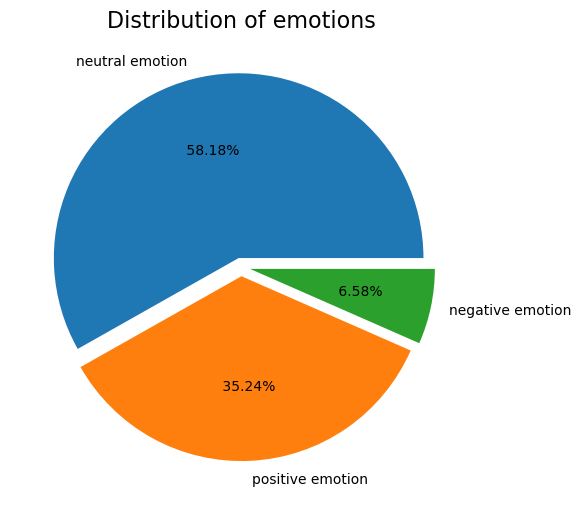

In [32]:
# Creating a pie chart for the target variable
label = ["neutral emotion", "positive emotion", "negative emotion"]
plt.figure(figsize = (6,6))
plt.pie(data["emotion"].value_counts(), labels=label, autopct= " %.2f%%", explode=(0.05, 0.05, 0.05))
plt.title("Distribution of emotions", fontsize = 16)
plt.tight_layout
plt.show;

Observations: Negative emotions had the highest percentage of the emotions. Class imbalance is evident which will need to be handled

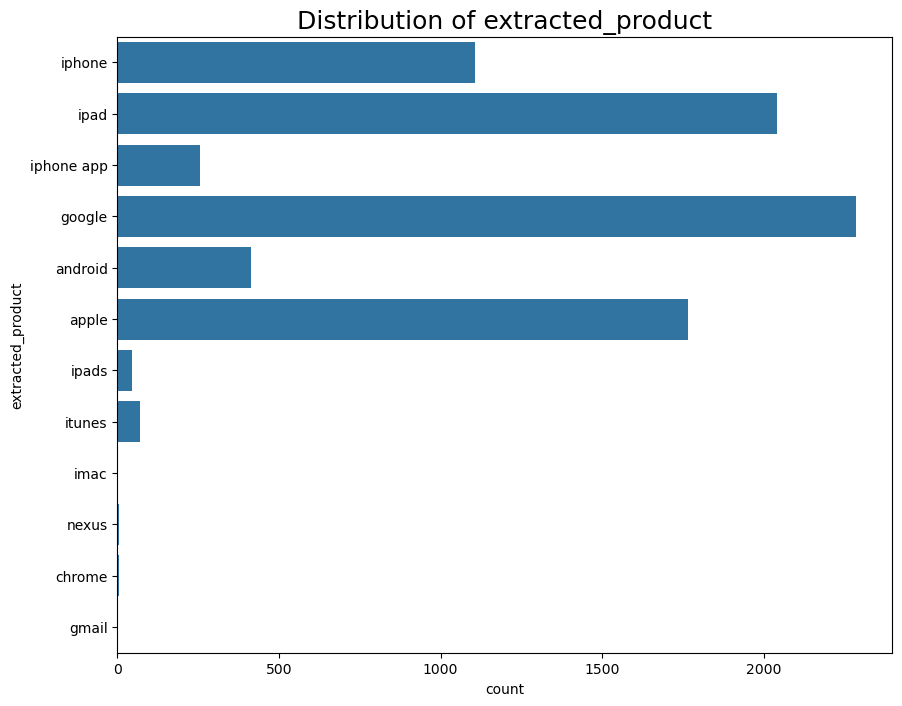

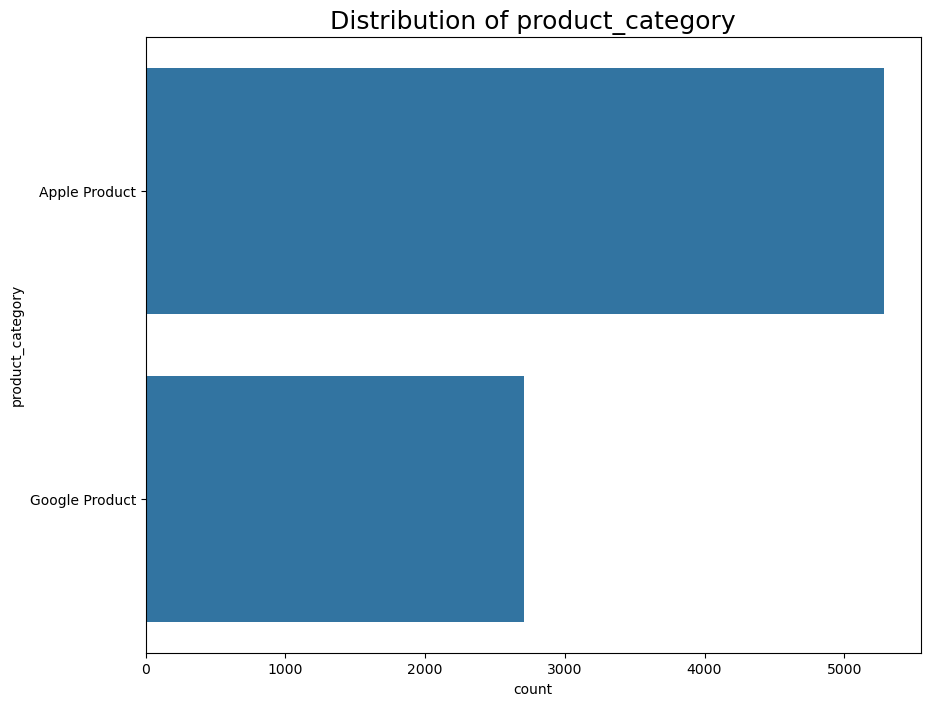

In [33]:
# Using a for loop to create a countplot for the categorical columns
categorical_cols = [
'extracted_product', 'product_category'
 ]
for col in categorical_cols:
   plt.figure(figsize=(10,8))
   sns.countplot(data = data, y= col)
   plt.title(f"Distribution of {col}", fontsize=18)
   plt.show()


Observations: Most of the tweets had neutral reactions implying that 

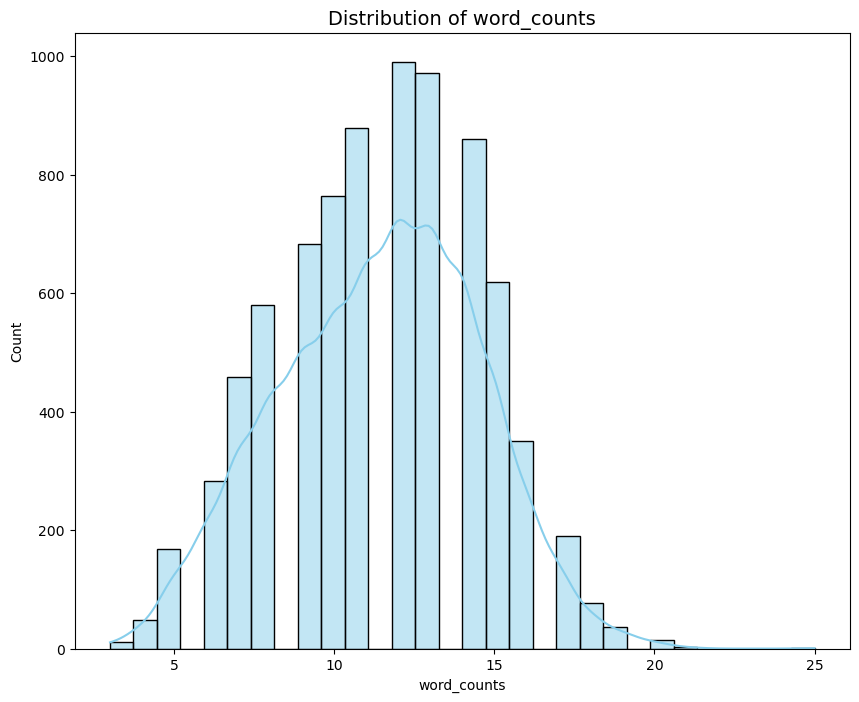

In [34]:
# Creating a histplot for the numerical column
plt.figure(figsize=(10,8))
sns.histplot(data['word_counts'], kde=True, bins=30, color="skyblue")
plt.title(f'Distribution of word_counts', fontsize=14)
plt.xlabel('word_counts')
plt.ylabel('Count')
plt.show();


Observations: 

## Bivariate Analysis

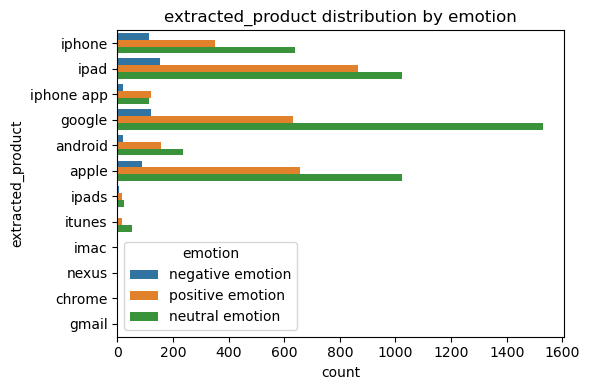

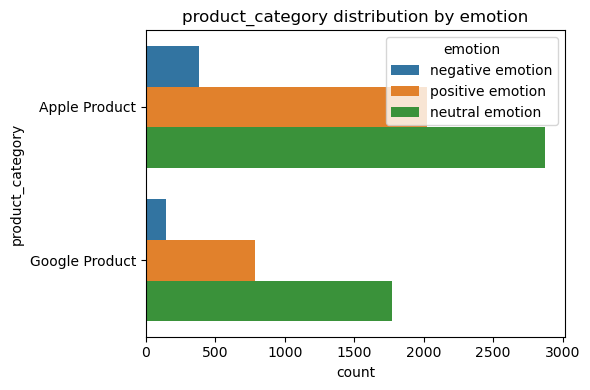

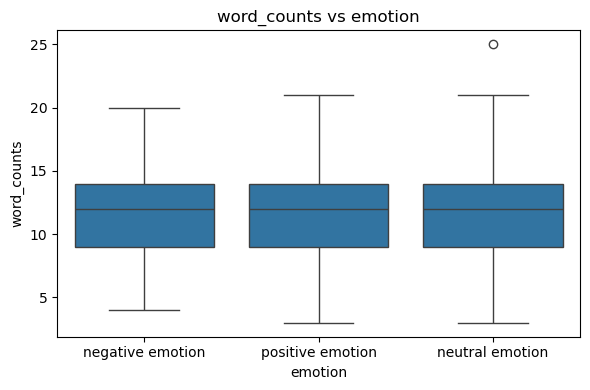

In [36]:
# Using  for loop to plot the categorical and numerical faetures against the target variable
target = 'emotion'  
features = 'extracted_product', 'product_category', 'word_counts'

for col in features:
    plt.figure(figsize=(6,4))
    
    # Numerical features
    if data[col].dtype != 'object':
        sns.boxplot(x = target, y = col, data = data)
        plt.title(f'{col} vs {target}')
    
    # Categorical features
    else:
        sns.countplot(y = col, hue = target, data = data)
        plt.title(f'{col} distribution by {target}')
    
    plt.tight_layout()
    plt.show()


Observations: 

## Multivariate Analysis

In [37]:
#Get positve tweets
positive_words = ' '.join([text for text in data['cleaned_tweet_text'][data['emotion'] == 'positive emotion']])

#Get negative tweets
negative_words = ' '.join([text for text in data['cleaned_tweet_text'][data['emotion'] == 'negative emotion']])


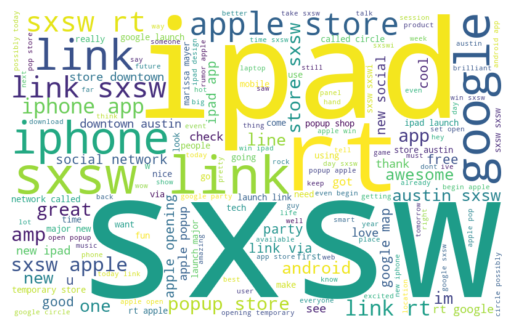

In [38]:
wordcloud = WordCloud(width=800, height=500,
                      background_color='white',
                      min_font_size=10).generate(positive_words)

plt.figure(figsize=(8, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off');

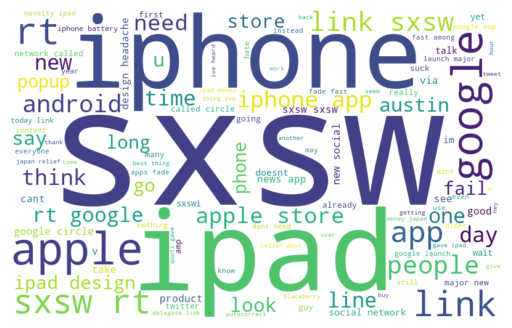

In [39]:
wordcloud = WordCloud(width=800, height=500,
                      background_color='white',
                      min_font_size=10).generate(negative_words)

plt.figure(figsize=(8, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off');

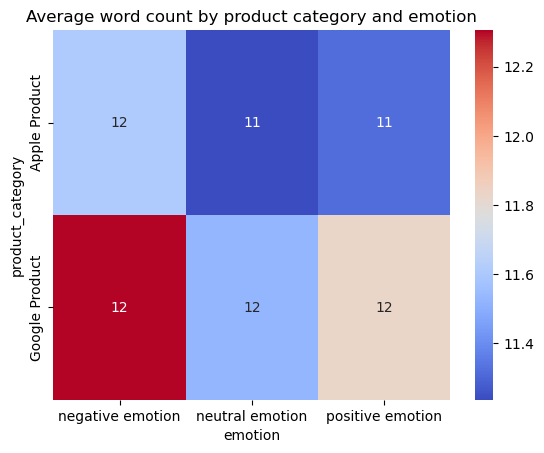

In [ ]:
# 
pivot = data.pivot_table(values='word_counts', index='product_category', columns='emotion', aggfunc='mean')

sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title('Average word count by product category and emotion')
plt.show()


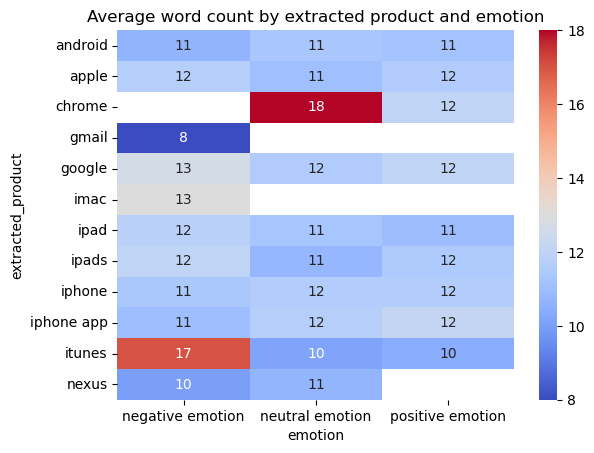

In [42]:
# 
pivot = data.pivot_table(values='word_counts', index='extracted_product', columns='emotion', aggfunc='mean')

sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title('Average word count by extracted product and emotion')
plt.show()


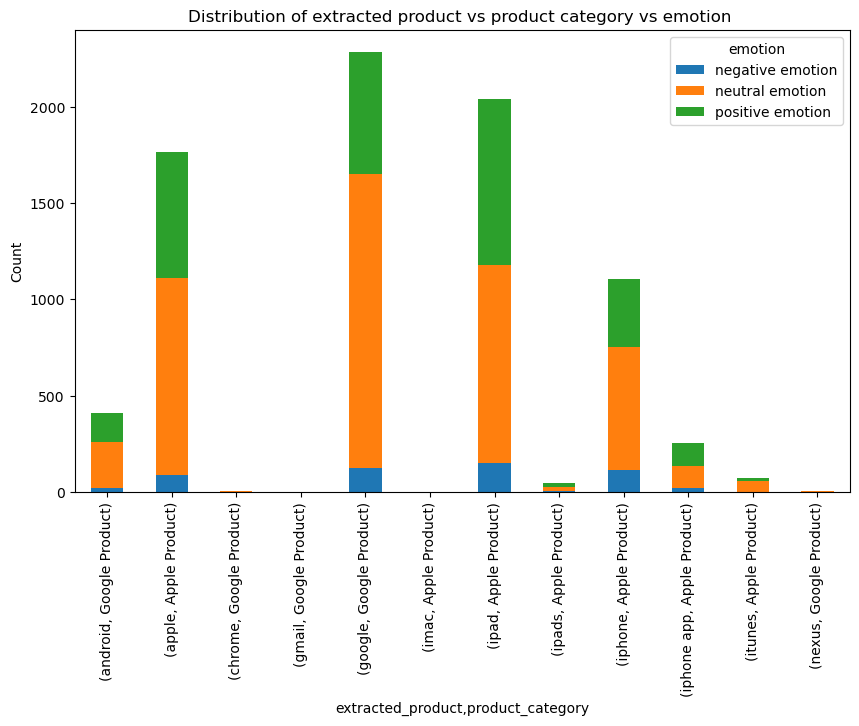

In [ ]:
# Creating a crosstab
cross = pd.crosstab([data['extracted_product'], data['product_category']], data['emotion'])

# Plotting a stacked bar
cross.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Distribution of extracted product vs product category vs emotion ')
plt.ylabel('Count')
plt.show()



Observations: 

In [40]:
# def top_ngrams(texts, n=1, top_k=15, stop_words="english"):
#     vec = CountVectorizer(ngram_range=(n, n), stop_words=stop_words, min_df=1)
#     X = vec.fit_transform(texts)
#     counts = np.asarray(X.sum(axis=0)).ravel()
#     vocab = np.array(vec.get_feature_names_out())
#     idx = counts.argsort()[::-1][:top_k]
#     return pd.DataFrame({"ngram": vocab[idx], "count": counts[idx]})

# # Group the data by the target variable 
# groups = {
#     sentiment: subset 
#     for sentiment, subset in data.groupby('cleaned_tweet_text')
# }


# for bucket, d in groups.items():
#     print(f"\n=== Top unigrams — {bucket} ===")
#     display(top_ngrams(d["cleaned_tweet_text"], n=1, top_k=15))
#     print(f"=== Top bigrams — {bucket} ===")
#     display(top_ngrams(d["cleaned_tweet_text"], n=2, top_k=15))